# Лабораторная работа 3: KNN и кросс-валидация

**Датасет:** Breast Cancer Wisconsin (диагностика рака молочной железы)

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Загрузка данных
cancer = load_breast_cancer()
print(f"Размер данных: {cancer.data.shape}")
print(f"Классы: {cancer.target_names}")

Размер данных: (569, 30)
Классы: ['malignant' 'benign']


In [3]:
# Проверка на пропуски
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
print(f"Пропуски: {df.isnull().sum().sum()}")

Пропуски: 0


In [4]:
# 1. Формирование обучающей и тестовой выборки
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.3, random_state=42)

In [5]:
# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.fit_transform(cancer.data)

In [6]:
# 2. Первичное обучение модели и оценка качества (произвольное K=50)
knn1 = KNeighborsClassifier(n_neighbors=50)
knn1.fit(X_train_scaled, y_train)
y_pred_train1 = knn1.predict(X_train_scaled)
y_pred_test1 = knn1.predict(X_test_scaled)
accuracy_score(y_train, y_pred_train1), accuracy_score(y_test, y_pred_test1)

(0.949748743718593, 0.9473684210526315)

In [7]:
# 3. Оценка качества модели с использованием кросс-валидации
# Стратегия 1: StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = cross_val_score(KNeighborsClassifier(n_neighbors=50), X_scaled, cancer.target, cv=skf)
scores_skf, np.mean(scores_skf)

(array([0.98245614, 0.92105263, 0.92982456, 0.96491228, 0.96460177]),
 np.float64(0.9525694767893184))

In [8]:
# Стратегия 2: StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
scores_sss = cross_val_score(KNeighborsClassifier(n_neighbors=50), X_scaled, cancer.target, cv=sss)
scores_sss, np.mean(scores_sss)

(array([0.94736842, 0.9122807 , 0.97368421, 0.97368421, 0.94736842]),
 np.float64(0.9508771929824562))

In [9]:
# 4. Подбор гиперпараметров на основе решетчатого поиска и кросс-валидации
n_range = np.arange(1, 52, 2)
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33,
         35, 37, 39, 41, 43, 45, 47, 49, 51])}]

In [10]:
%%time
# GridSearchCV со StratifiedKFold (стратегия 1)
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=skf, scoring='accuracy')
clf_gs.fit(X_train_scaled, y_train)

CPU times: user 585 ms, sys: 695 ms, total: 1.28 s
Wall time: 113 ms


,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': array([ 1, 3..., 47, 49, 51])}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(9)


In [11]:
# Лучшие параметры
clf_gs.best_params_

{'n_neighbors': np.int64(9)}

In [12]:
# Лучшее значение метрики
clf_gs.best_score_

np.float64(0.9598417721518986)

Text(0, 0.5, 'accuracy')

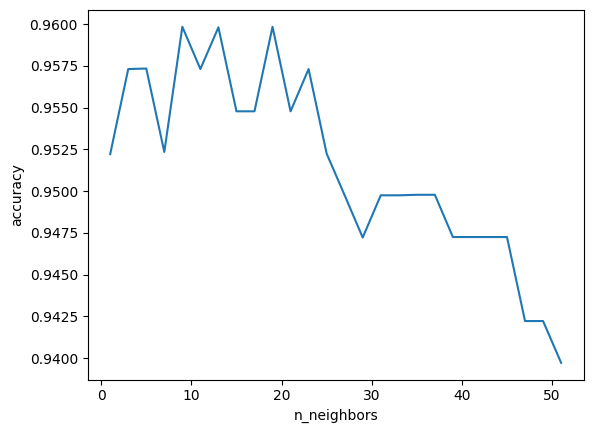

In [13]:
# Визуализация зависимости accuracy от K
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'])
plt.xlabel('n_neighbors')
plt.ylabel('accuracy')

In [14]:
%%time
# RandomizedSearchCV со StratifiedShuffleSplit (стратегия 2)
clf_rs = RandomizedSearchCV(KNeighborsClassifier(), tuned_parameters, cv=sss, scoring='accuracy')
clf_rs.fit(X_train_scaled, y_train)

CPU times: user 218 ms, sys: 284 ms, total: 502 ms
Wall time: 45.3 ms


,estimator,KNeighborsClassifier()
,param_distributions,"[{'n_neighbors': array([ 1, 3..., 47, 49, 51])}]"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedShu...ain_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [15]:
clf_rs.best_score_, clf_rs.best_params_

(np.float64(0.9574999999999999), {'n_neighbors': np.int64(17)})

Text(0, 0.5, 'accuracy')

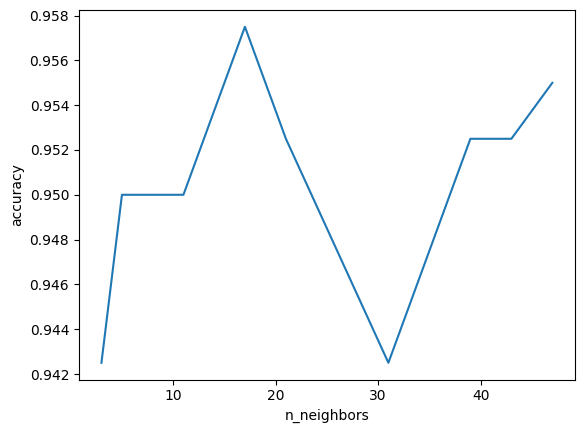

In [16]:
# Визуализация зависимости accuracy от K
rs_results = pd.DataFrame(clf_rs.cv_results_)
rs_results = rs_results.sort_values('param_n_neighbors')
plt.plot(rs_results['param_n_neighbors'], rs_results['mean_test_score'])
plt.xlabel('n_neighbors')
plt.ylabel('accuracy')

In [17]:
# 5. Обучение модели и оценка качества с учетом подобранных гиперпараметров
clf_gs.best_estimator_.fit(X_train_scaled, y_train)
y_pred_train2 = clf_gs.best_estimator_.predict(X_train_scaled)
y_pred_test2 = clf_gs.best_estimator_.predict(X_test_scaled)

In [18]:
# Новое качество модели (после подбора гиперпараметров)
accuracy_score(y_train, y_pred_train2), accuracy_score(y_test, y_pred_test2)

(0.9773869346733668, 0.9707602339181286)

In [19]:
# Качество модели до подбора гиперпараметров
accuracy_score(y_train, y_pred_train1), accuracy_score(y_test, y_pred_test1)

(0.949748743718593, 0.9473684210526315)

In [20]:
print("Сравнение моделей")
print(f"\nИсходная модель (K=50):")
print(f"  Точность на обучающей: {accuracy_score(y_train, y_pred_train1):.4f}")
print(f"  Точность на тестовой:  {accuracy_score(y_test, y_pred_test1):.4f}")

print(f"\nОптимальная модель (K={clf_gs.best_params_['n_neighbors']}):")
print(f"  Точность на обучающей: {accuracy_score(y_train, y_pred_train2):.4f}")
print(f"  Точность на тестовой:  {accuracy_score(y_test, y_pred_test2):.4f}")

print(f"\nУлучшение на тестовой выборке: {accuracy_score(y_test, y_pred_test2) - accuracy_score(y_test, y_pred_test1):.4f}")

Сравнение моделей

Исходная модель (K=50):
  Точность на обучающей: 0.9497
  Точность на тестовой:  0.9474

Оптимальная модель (K=9):
  Точность на обучающей: 0.9774
  Точность на тестовой:  0.9708

Улучшение на тестовой выборке: 0.0234


In [21]:
print("Сводка результатов подбора")
print(f"GridSearchCV + StratifiedKFold:              best_score={clf_gs.best_score_:.4f}, K={clf_gs.best_params_['n_neighbors']}")
print(f"RandomizedSearchCV + StratifiedShuffleSplit: best_score={clf_rs.best_score_:.4f}, K={clf_rs.best_params_['n_neighbors']}")

Сводка результатов подбора
GridSearchCV + StratifiedKFold:              best_score=0.9598, K=9
RandomizedSearchCV + StratifiedShuffleSplit: best_score=0.9575, K=17


## Выводы

1. Использован датасет Breast Cancer Wisconsin (569 образцов, 30 признаков, бинарная классификация)
2. Пропусков в данных нет
3. Данные разделены на обучающую и тестовую выборки (70/30)
4. Обучена исходная модель KNN с произвольным K=50
5. Выполнен подбор гиперпараметра K с использованием двух стратегий кросс-валидации для классификации:
   - **GridSearchCV + StratifiedKFold** — стратифицированная K-fold кросс-валидация (сохраняет пропорции классов в каждом фолде)
   - **RandomizedSearchCV + StratifiedShuffleSplit** — стратифицированное случайное разбиение (сохраняет пропорции классов при случайном разбиении)
6. Оптимальная модель показала улучшение качества по сравнению с исходной